# TP4 :  Low-budget  Learning

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data are available for training, say 

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small. Hence we are not in the context of classical well-organized benchmark datasets.

To make your life easier, you also get a validation set $\mathcal{X}_{\text{val}}$ representative of the test set, but you cannot use it for training. You can only use it to select the best model and hyperparameters.

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible. We also assume that we have a limited computational budget (e.g., limited GPU access).


In this practical, we will use the `resnet10` architecture. 

# QUESTIONS

## Grading

You will need to provide 4 files : 
1. This Notebook
2. `utils.py`
3. `drawing_lora.png`
4. `cutmix.png`

Some of the code will be automatically graded so please follow the instructions carefully.

You will also need to participate in a competition on https://www.codabench.org to get your model evaluated on the hidden test set (the link to the competition will be provided on the course forum). Before submitting anything make sure to read the instructions on the competition page. The evaluation metric is the accuracy. However, *this is not a competition* as it is not necessary to get the best score to get a good grade. If you get a good score, and follow the instructions, you will get a good grade.

`utils.py` will be imported during the testing phase so please make sure:
- it does not execute any code when imported
- it does not depend on any module that is not standard (e.g., not `torch`, `torchvision`, `numpy`, etc.)


General instructions:
- Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).
- For each question that involves training a model:
    - Give the number of trained parameters.
    - You must provide the training curves (train & validation accuracy/loss vs epochs) in the notebook.
    - You must explain the choices you made (hyperparameters, etc). (A short justification is enough. For instance, "I used default hyperparameters." does not need further explanation. Or "I tried (0.1,0.01,0.001) and picked 0.01 because it gave the best validation accuracy." is enough.)
    - You must comment on the accuracy obtained.
- If you use a seed for reproducibility, please make sure it is a personal one using something like `hash("your_firstname_your_lastname")`.

<div class="alert alert-info">  Example of answer  </div>

In [43]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
from torchmetrics.classification import ConfusionMatrix


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [44]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
if not os.path.exists("data/TP4_images/north_dataset_test"):
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"

In [45]:
val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)

train_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)


metric = ConfusionMatrix(task="multiclass", num_classes=2).to(device)


def model_instancier(**kwargs):
    """
    Instanciate a ResNet10 model (ResNet18 with only 1 block per layer).

    Parameters
    ----------
    **kwargs: dict
        Keyword arguments to pass to the ResNet18 constructor.

    Returns
    -------
    model: nn.Module
        The instantiated ResNet10 model.
    """
    _model = models.resnet18(**kwargs)
    for i in range(1, 5):
        setattr(_model, f"layer{i}", getattr(_model, f"layer{i}")[0])
    return _model


base_model = model_instancier()
classifier_name = "fc"


print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 42
Validation dataset size: 42


## Question 1: 
>  Create `last_layer.py` to change the last layer of the resnet model so that it fits the problem.

In [12]:
from last_layer import LastLayer

setattr(base_model, classifier_name, LastLayer())
assert (
    getattr(base_model, classifier_name).out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.

## Question 2: 
> Provide a function `precompute_features` in `utils.py` that creates a new dataset from the features precomputed by the model.

In [5]:
def precompute_features(
    model: models.ResNet,
    dataset: torch.utils.data.Dataset,
    device: torch.device,
) -> torch.utils.data.Dataset:
    """
    Create a new dataset with the features precomputed by the model.

    If the model is $f \circ g$ where $f$ is the last layer and $g$ is
    the rest of the model, it is not necessary to recompute $g(x)$ at
    each epoch as $g$ is fixed. Hence you can precompute $g(x)$ and
    create a new dataset
    $\mathcal{X}_{\text{train}}' = \{(g(x_n),y_n)\}_{n\leq N_{\text{train}}}$

    Arguments:
    ----------
    model: models.ResNet
        The model used to precompute the features
    dataset: torch.utils.data.Dataset
        The dataset to precompute the features from
    device: torch.device
        The device to use for the computation

    Returns:
    --------
    torch.utils.data.Dataset
        The new dataset with the features precomputed
    """
    model.eval()
    model.to(device)

    # Remove the last layer
    feature_extractor = nn.Sequential(*list(model.children())[:-1])

    features_list = []
    labels_list = []
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False)

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = feature_extractor(images)
            features = features.squeeze()
            features_list.append(features.cpu())
            labels_list.append(labels)

    features_tensor = torch.cat(features_list)
    labels_tensor = torch.cat(labels_list)

    return torch.utils.data.TensorDataset(features_tensor, labels_tensor)


## Question 3: 
> Train the last layer of a randomly initialized resnet model.  Provide the training process in the notebook with training curve. Comment on the accuracy. 

In [65]:
from utils import precompute_features

In [66]:
base_model = model_instancier()
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

print(
    "Class distribution in the training set:",
    torch.bincount(train_features_dataset.tensors[1]),
)
print(
    "Class distribution in the validation set:",
    torch.bincount(val_features_dataset.tensors[1]),
)

Class distribution in the training set: tensor([31, 11])
Class distribution in the validation set: tensor([21, 21])


In [71]:
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Setup the dataloaders and parameters
batch_size = 32
train_loader = DataLoader(train_features_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_features_dataset, batch_size=batch_size, shuffle=False)

epochs = 5
lr = 0.001
criterion = nn.CrossEntropyLoss()

# We only give the last layer to the optimizer and keep the rest of the model frozen
classifier = getattr(base_model, classifier_name)
optimizer = optim.Adam(classifier.parameters(), lr=lr)

total_params = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Training {total_params:,} individual parameters.")

train_acc, val_acc = [], []
train_loss, val_loss = [], []

for epoch in range(epochs):
    # Training
    classifier.train()
    running_loss, correct, total = 0, 0, 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = classifier(features)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss.append(running_loss / total)
    train_acc.append(correct / total)

    # Validation
    classifier.eval()
    running_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)

            outputs = classifier(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss.append(running_loss / total)
    val_acc.append(correct / total)

    print(
        f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_acc[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}"
    )

Training 1,026 individual parameters.
Epoch [1/5], Train Loss: 0.5915, Train Acc: 0.7381, Val Loss: 0.8094, Val Acc: 0.5000
Epoch [2/5], Train Loss: 0.5902, Train Acc: 0.7381, Val Loss: 0.8167, Val Acc: 0.5000
Epoch [3/5], Train Loss: 0.5906, Train Acc: 0.7381, Val Loss: 0.8148, Val Acc: 0.5000
Epoch [4/5], Train Loss: 0.5899, Train Acc: 0.7381, Val Loss: 0.8053, Val Acc: 0.5000
Epoch [5/5], Train Loss: 0.5893, Train Acc: 0.7381, Val Loss: 0.7998, Val Acc: 0.5000


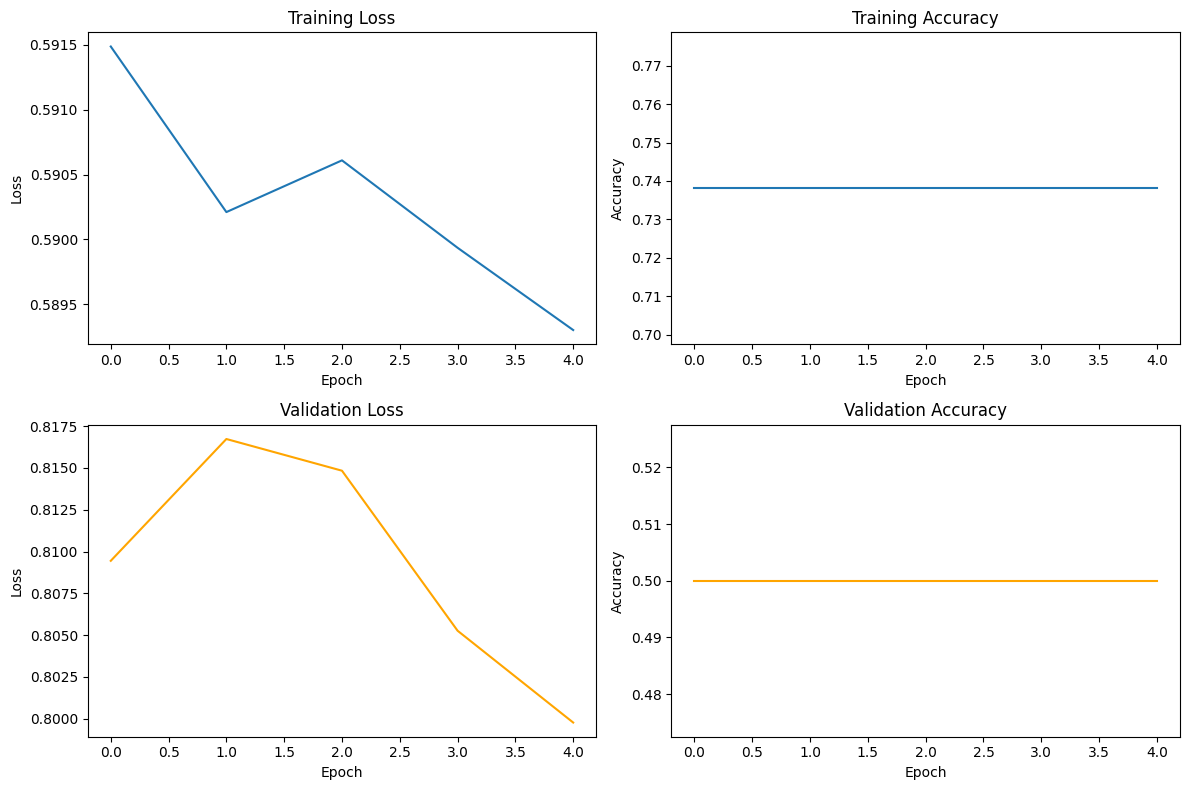

In [72]:
# Plotting the results

fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(train_loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 2, 2)
plt.plot(train_acc)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(2, 2, 3)
plt.plot(val_loss, c="orange")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 2, 4)
plt.plot(val_acc, c="orange")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

<div class="alert alert-info">  

We first load a pretrained ResNet-18 model and replace its final fully connected layer to adapt it to our binary classification task. All layers except the last one are frozen so that only the final classification layer is trained. This results in 1,026 trainable parameters. 

However, due to the very small and imbalanced dataset, the model performs poorly on both the training and test sets. The training set contains only 42 samples (31 from one class and 11 from the other), which is insufficient for the model to learn a meaningful decision boundary. The strong class imbalance further worsens the situation, as the model tends to predict the majority class for most inputs.

This behavior is evident in the training accuracy stabilizing at 73.81%, which closely matches the proportion of the majority class (31/42 $\approx$ 74%). The test accuracy of 50% further highlights the lack of generalization, corresponding to near-random performance on unseen data.

The hyperparameters were selected based on standard practices for training a linear classifier. We used a learning rate of 0.001 (alternative values of 0.01 and 0.0001 were also tested but did not improve performance) and trained the model for 5 epochs, which was sufficient for convergence given the small dataset size and the observed training logs. The batch size was set to 32, balancing computational efficiency and stable gradient estimation.

To address the class imbalance, we tried to implement a class-weighted loss function. However, this did not significantly improve performance. When the class weights were similar, their impact was negligible and the model continued predicting the majority class. Conversely, when the weights were strongly skewed, training became unstable and performance degraded further.

Overall, the combination of severe class imbalance, extremely limited data, and freezing all but the final layer severely restricts the model’s ability to adapt, resulting in poor and non-generalizable performance under these conditions.

</div>

## Question 4:
>  Now start from a pretrained model on imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve. 

This is the first question evaluated on the codabench platform.

In [73]:
base_model = models.resnet18(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

In [74]:
train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

In [76]:
# Setup the dataloaders and parameters
batch_size = 32
train_loader = DataLoader(train_features_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_features_dataset, batch_size=batch_size, shuffle=False)

epochs = 5
lr = 0.0035
criterion = nn.CrossEntropyLoss()

# We only give the last layer to the optimizer and keep the rest of the model frozen
classifier = getattr(base_model, classifier_name)
optimizer = optim.Adam(classifier.parameters(), lr=lr)

total_params = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Training {total_params:,} individual parameters.")

train_acc, val_acc = [], []
train_loss, val_loss = [], []

for epoch in range(epochs):
    # Training
    classifier.train()
    running_loss, correct, total = 0, 0, 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = classifier(features)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss.append(running_loss / total)
    train_acc.append(correct / total)

    # Validation
    classifier.eval()
    running_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)

            outputs = classifier(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss.append(running_loss / total)
    val_acc.append(correct / total)

    print(
        f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_acc[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}"
    )

Training 1,026 individual parameters.
Epoch [1/5], Train Loss: 0.2913, Train Acc: 0.9048, Val Loss: 0.3857, Val Acc: 0.8095
Epoch [2/5], Train Loss: 0.2313, Train Acc: 0.9286, Val Loss: 0.7878, Val Acc: 0.6190
Epoch [3/5], Train Loss: 0.2792, Train Acc: 0.8810, Val Loss: 0.5931, Val Acc: 0.6905
Epoch [4/5], Train Loss: 0.1993, Train Acc: 0.9286, Val Loss: 0.3619, Val Acc: 0.8095
Epoch [5/5], Train Loss: 0.1761, Train Acc: 0.9524, Val Loss: 0.3361, Val Acc: 0.8810


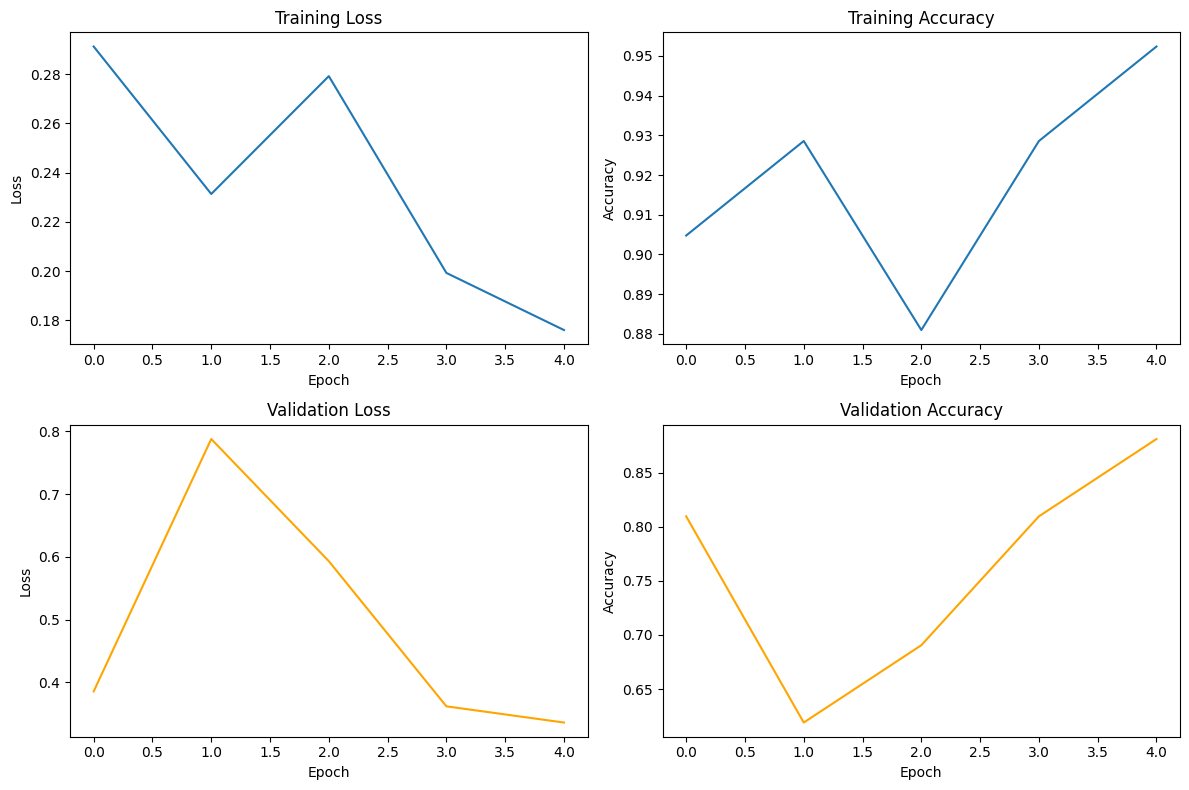

In [77]:
# Plotting the results

fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(train_loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 2, 2)
plt.plot(train_acc)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(2, 2, 3)
plt.plot(val_loss, c="orange")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 2, 4)
plt.plot(val_acc, c="orange")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

<div class="alert alert-info"> 

We repeat the same procedure as in Question 3, but this time we initialize the model with pretrained weights from ResNet-18. As before, only the final fully connected layer is trained, resulting in 1,026 trainable parameters.

Under this configuration, the model achieves a significantly higher training accuracy of 95.24% and a test accuracy of 88.10%. The pretrained network has already learned rich and general visual features from the ImageNet, enabling it to adapt effectively to our small and imbalanced dataset, even when only the final layer is updated.

The hyperparameters were selected based on standard practice and empirical evaluation. A learning rate of 0.0035 was chosen, as it produced better results than alternative values such as 0.001 and 0.0005. Training for 5 epochs was sufficient for convergence, given the dataset size and the observed training dynamics. The batch size was kept at 32 to ensure computational efficiency and stable gradient estimates.

In conclusion, leveraging pretrained features provides a strong initialization that substantially improves performance compared to training from scratch. These results clearly illustrate the effectiveness of transfer learning in low-data settings.

</div>

### Save your model

In [78]:
# Save the last layer weights for grading on codabench
torch.save(getattr(base_model, classifier_name).state_dict(), "last_layer_finetune.pth")

### Check that you can load your model

In [79]:
model = model_instancier(weights="DEFAULT")
fc = LastLayer()
fc.load_state_dict(
    torch.load("last_layer_finetune.pth", weights_only=True, map_location=device)
)
setattr(model, classifier_name, fc)
model.eval()
pass

## Question 5:
> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  ( We are perfectly fine if you use external library for this question only ) 

Intermediate question : Describe LoRA and the difference with LoRA for Convolutions in this paper : https://arxiv.org/pdf/2401.17868  in a few lines  (you do not have to implement ConvLora)

<div class="alert alert-info"> 

LoRA (Low-Rank Adaptation) is a technique designed to efficiently fine-tune large pre-trained models while keeping most of their original weights frozen. Instead of updating all the parameters of the model during fine-tuning, LoRA introduces low-rank matrices that are added to the original weights. This allows the model to adapt to new tasks with a significantly reduced number of trainable parameters, leading to lower computational costs and memory usage.

For convolutional layers, one common approach is the bottleneck decomposition. In this method, a low-rank residual path is added in parallel to the original convolutional layer. This residual path consists of two convolutional layers: the first layer reduces the number of channels and the second layer restores it back to the original size. This way, the model can learn task-specific features through the low-rank path while keeping the majority of the pre-trained weights unchanged.

In our implementation, we applied this approach to the each convolutional layer of the ResNet18 model using the peft library. These layers are choosen because they capture essential spatial features in the input data while still benefiting from lightweight adaptation through LoRA.

A drawing of the LoRA process is provided in the `drawing_lora.png` file.

</div>

In [25]:
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

In [26]:
from peft import LoraConfig, get_peft_model

# Define LoRA configuration and apply it to the model with the targets being the first two convolutional layers
lora_config = LoraConfig(
    r=8, lora_alpha=16, target_modules=["conv1", "conv2"], lora_dropout=0.1, bias="none"
)

lora_model = get_peft_model(base_model, lora_config)
lora_model.to(device)
lora_model.print_trainable_parameters()

trainable params: 123,032 || all params: 5,029,850 || trainable%: 2.4460


In [27]:
# Setup the dataloaders and parameters
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

epochs = 30
lr = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lora_model.parameters(), lr=lr)

train_acc, val_acc = [], []
train_loss, val_loss = [], []

for epoch in range(epochs):
    # Training
    lora_model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = lora_model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss.append(running_loss / total)
    train_acc.append(correct / total)

    # Validation
    lora_model.eval()
    running_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = lora_model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss.append(running_loss / total)
    val_acc.append(correct / total)

    print(
        f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_acc[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}"
    )

Epoch [1/30], Train Loss: 0.6770, Train Acc: 0.7381, Val Loss: 0.6909, Val Acc: 0.5000
Epoch [2/30], Train Loss: 0.6725, Train Acc: 0.7619, Val Loss: 0.6860, Val Acc: 0.5000
Epoch [3/30], Train Loss: 0.6626, Train Acc: 0.9286, Val Loss: 0.6793, Val Acc: 0.5000
Epoch [4/30], Train Loss: 0.6511, Train Acc: 0.9524, Val Loss: 0.6677, Val Acc: 0.5714
Epoch [5/30], Train Loss: 0.6213, Train Acc: 0.9762, Val Loss: 0.6462, Val Acc: 0.7381
Epoch [6/30], Train Loss: 0.5894, Train Acc: 0.9524, Val Loss: 0.6100, Val Acc: 0.7619
Epoch [7/30], Train Loss: 0.5603, Train Acc: 0.9048, Val Loss: 0.5695, Val Acc: 0.6429
Epoch [8/30], Train Loss: 0.5197, Train Acc: 0.9524, Val Loss: 0.5532, Val Acc: 0.6667
Epoch [9/30], Train Loss: 0.4783, Train Acc: 0.9286, Val Loss: 0.5528, Val Acc: 0.6667
Epoch [10/30], Train Loss: 0.4513, Train Acc: 0.9286, Val Loss: 0.5203, Val Acc: 0.7143
Epoch [11/30], Train Loss: 0.4274, Train Acc: 0.9762, Val Loss: 0.4647, Val Acc: 0.7857
Epoch [12/30], Train Loss: 0.3978, Train 

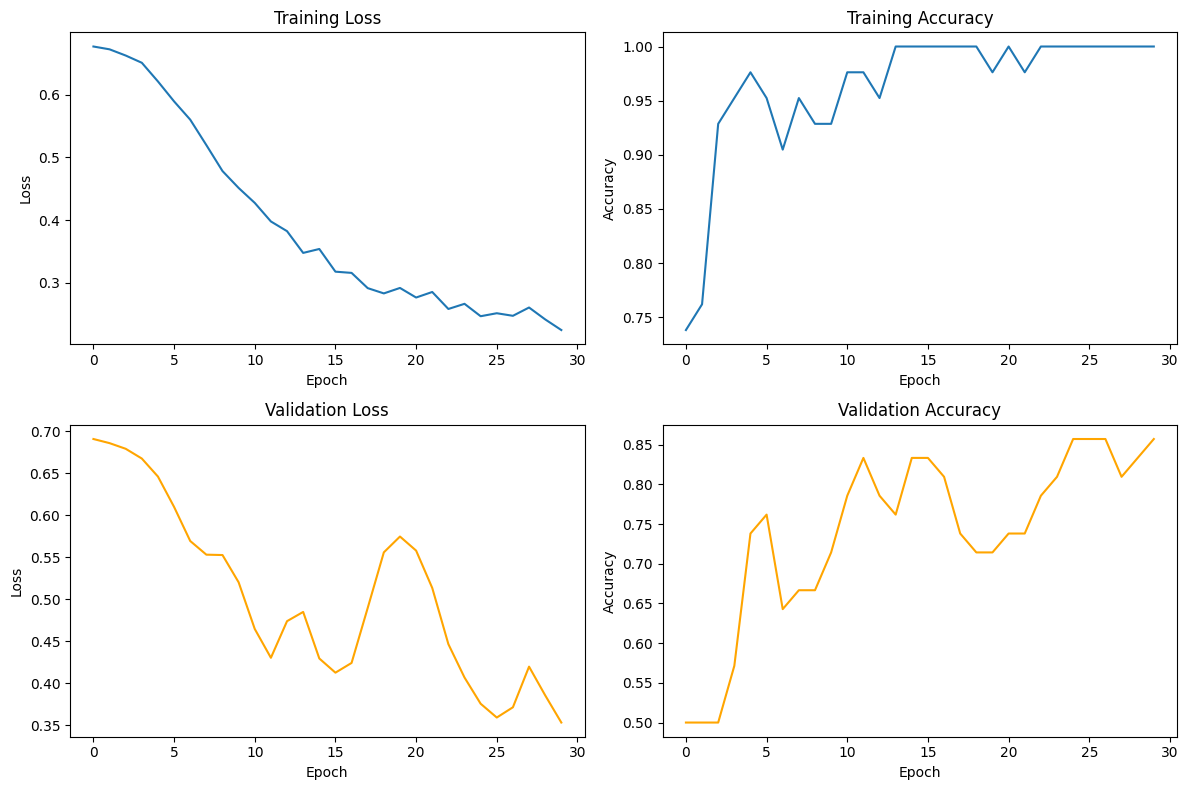

In [29]:
from matplotlib import pyplot as plt

# Plotting the results

fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(train_loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 2, 2)
plt.plot(train_acc)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(2, 2, 3)
plt.plot(val_loss, c="orange")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 2, 4)
plt.plot(val_acc, c="orange")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

<div class="alert alert-info">

To implement LoRA on ResNet-18, we use the PEFT library, which provides a convenient interface for applying low-rank adaptations to pretrained models. LoRA modules are inserted into each convolutional layer of the ResNet-18 architecture, enabling parameter-efficient fine-tuning.

With this approach, the number of trainable parameters is reduced to 123.032. Although this is higher than the 1,026 parameters trained in Question 4 (where only the final layer was optimized), it remains significantly lower than the approximately 11 million parameters of the full model.

Using LoRA, we achieve a training accuracy close to 100% and a test accuracy of around 85%. This performance remains satisfactory given the small dataset size and the fact that only a subset of parameters is updated. The LoRA mechanism allows the model to better adapt to the specific characteristics of our dataset while still leveraging the pretrained backbone, resulting in improved flexibility compared to training only the final classification layer.

Regarding hyperparameters, we again relied on standard fine-tuning practices. A learning rate of 0.001 was selected (alternative values such as 0.01 and 0.0001 were tested but did not yield better results), and the model was trained for 30 epochs, ensuring convergence according to the training logs. The steady increase in training accuracy, reaching nearly 100%, suggests potential overfitting to the small training set. The batch size was set to 32 to ensure efficient computation and stable gradient estimation.

Overall, LoRA provides a strong trade-off between adaptability and parameter efficiency, enabling competitive performance while avoiding full fine-tuning of the entire network.

<div>

## Question 6:
> Let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them into your training pipeline.

Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing. 

You can find many other data augmentation techniques here: https://docs.pytorch.org/vision/0.15/transforms.html

This is the second question evaluated on the codabench platform.

<div class="alert alert-info"> 

CutMix is a data augmentation technique used during the training of deep learning models, particularly in image classification tasks. Instead of applying simple transformations like rotation or flipping, CutMix creates new training samples by cutting out a rectangular region from one image and pasting it onto another image. The labels of the new images are also mixed proportionally based on the area of the cut-out region, effectively creating a soft label that encourages the model to learn from both images simultaneously. This helps improve the model's robustness and generalization.

A drawing illustrating the CutMix process is provided in the `cutmix.png` file.
</div>

In [59]:
# Data augmentation
from torchvision.transforms import v2

import warnings

warnings.filterwarnings("ignore", category=UserWarning)

transform = v2.Compose(
    [
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomRotation(degrees=15),
        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        v2.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
        v2.ToTensor(),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Reload the datasets with the new transform + CutMix
train_dataset_aug = datasets.ImageFolder(
    dir_path + "north_dataset_sample", transform=transform
)
val_dataset_aug = datasets.ImageFolder(
    dir_path + "north_dataset_test", transform=transform
)
cutmix = v2.CutMix(num_classes=2)

In [60]:
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

lora_config = LoraConfig(
    r=8, lora_alpha=16, target_modules=["conv1", "conv2"], lora_dropout=0.1, bias="none"
)

lora_model = get_peft_model(base_model, lora_config)
lora_model.to(device)
lora_model.print_trainable_parameters()

trainable params: 123,032 || all params: 5,029,850 || trainable%: 2.4460


In [61]:
# Setup the dataloaders and parameters
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

epochs = 30
lr = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lora_model.parameters(), lr=lr)

cutmix_prob = 0.5

train_loss, val_loss = [], []
# Since CutMix introduces soft labels, we cannot compute accuracy on the train set anymore and will only look at the loss.
val_acc = []
best_val_acc = 0
best_model_state = None

for epoch in range(epochs):
    # Training
    lora_model.train()
    running_loss = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        # Apply CutMix with a given probability
        if torch.rand(1).item() < cutmix_prob:
            features, labels = cutmix(features, labels)

        optimizer.zero_grad()
        outputs = lora_model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

    train_loss.append(running_loss / len(train_loader.dataset))

    # Validation
    lora_model.eval()
    running_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)

            outputs = lora_model(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss.append(running_loss / total)
    val_acc.append(correct / total)

    if val_acc[-1] > best_val_acc:
        best_val_acc = val_acc[-1]
        best_model_state = lora_model.state_dict()

    print(
        f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_loss[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}"
    )

Epoch [1/30], Train Loss: 0.6769, Val Loss: 0.6859, Val Acc: 0.5000
Epoch [2/30], Train Loss: 0.6734, Val Loss: 0.6801, Val Acc: 0.5238
Epoch [3/30], Train Loss: 0.6717, Val Loss: 0.6752, Val Acc: 0.5714
Epoch [4/30], Train Loss: 0.6574, Val Loss: 0.6694, Val Acc: 0.6190
Epoch [5/30], Train Loss: 0.6490, Val Loss: 0.6585, Val Acc: 0.6667
Epoch [6/30], Train Loss: 0.5996, Val Loss: 0.6321, Val Acc: 0.6905
Epoch [7/30], Train Loss: 0.5693, Val Loss: 0.5878, Val Acc: 0.7381
Epoch [8/30], Train Loss: 0.5251, Val Loss: 0.5336, Val Acc: 0.7857
Epoch [9/30], Train Loss: 0.5345, Val Loss: 0.4922, Val Acc: 0.7619
Epoch [10/30], Train Loss: 0.5589, Val Loss: 0.4687, Val Acc: 0.7857
Epoch [11/30], Train Loss: 0.4505, Val Loss: 0.4350, Val Acc: 0.8095
Epoch [12/30], Train Loss: 0.4381, Val Loss: 0.4172, Val Acc: 0.8095
Epoch [13/30], Train Loss: 0.4210, Val Loss: 0.3985, Val Acc: 0.8095
Epoch [14/30], Train Loss: 0.5034, Val Loss: 0.3766, Val Acc: 0.8095
Epoch [15/30], Train Loss: 0.3791, Val Loss

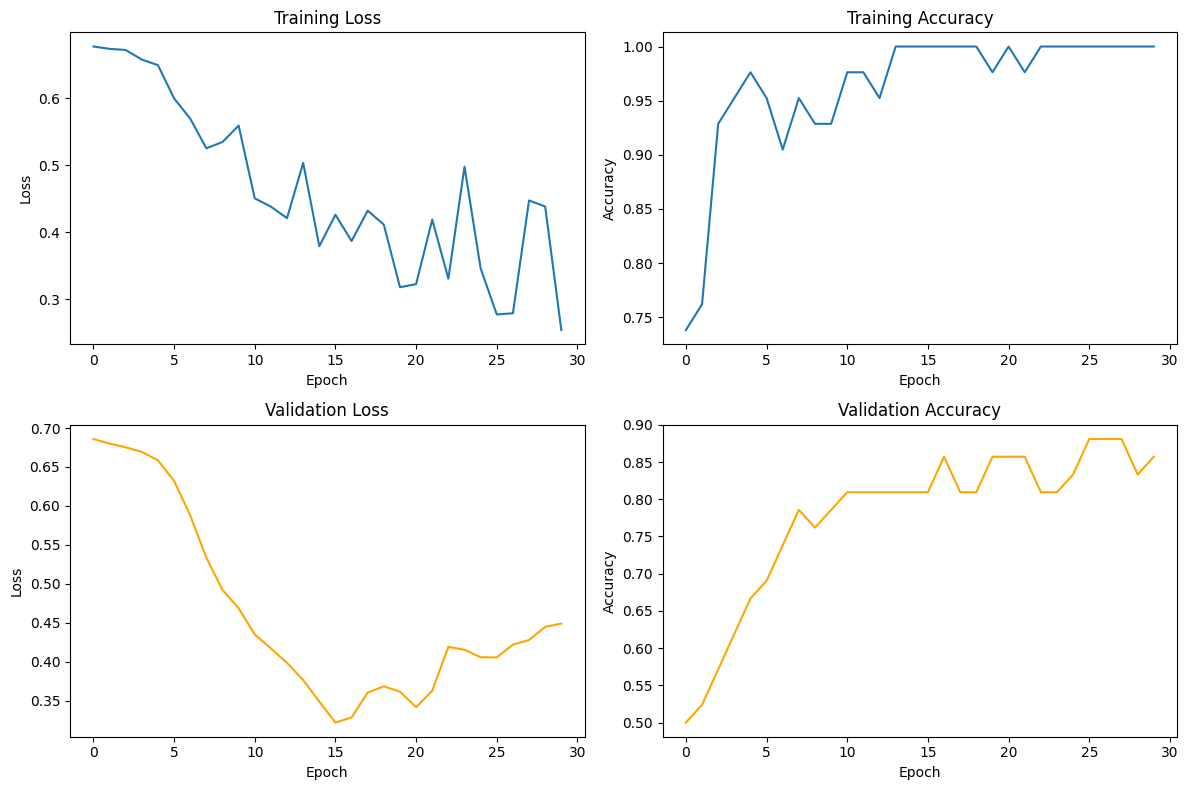

In [62]:
# Plotting the results

fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(train_loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 2, 2)
plt.plot(train_acc)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(2, 2, 3)
plt.plot(val_loss, c="orange")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 2, 4)
plt.plot(val_acc, c="orange")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

<div class="alert alert-info">

We incorporate CutMix into our training pipeline as a data augmentation strategy. At each training iteration, two images are randomly selected from the training set, and the CutMix transformation is applied to generate a new sample. This consists of cutting a random rectangular patch from one image and pasting it onto the other, while combining their labels proportionally to the area of the inserted region.

The hyperparameters remain similar to those used previously. We set the number of epochs to 30, same as before. The learning rate is set to 0.001 (alternative values such as 0.01 and 0.0001 were tested but did not produce better results), and the batch size remains 32, ensuring efficient computation and stable gradient estimates.

In practice, the performance achieved with CutMix is approximately the same as that obtained with LoRA alone. This suggests that although CutMix is generally an effective augmentation method, in our case the model may already be operating near its capacity given the small dataset size and the use of LoRA. Consequently, the additional variability introduced by CutMix does not lead to significant improvements.

It is possible that further tuning of the CutMix-specific parameters, such as the patch size distribution or mixing ratio, could yield better results. However, under the current configuration, the model’s performance remains comparable to that of the LoRA-only setup.

<div>

### Save your model

In [63]:
# Merge LoRA weights back into the base model
lora_model.load_state_dict(best_model_state)
merged_model = (
    lora_model.merge_and_unload()
)  # Merge LoRA weights back into the base model
assert isinstance(merged_model, models.ResNet)

torch.save(merged_model.state_dict(), "final_model.pth")

### Check that you can load your model

In [64]:
from last_layer import LastLayer

classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier(weights="DEFAULT")
setattr(model, classifier_name, LastLayer())

model.load_state_dict(
    torch.load("final_model.pth", weights_only=True, map_location=device)
)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): BasicBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel

<div class="alert alert-info">  With LoRA and Data Augmentation you should be able to improve your model's performance compared to only fine-tuning the last layer. </div>

# Some advice

In our experiments, we only used SGD and a laptop GPU. We recommend not hesitating to use a large number of epochs (e.g., 100, 200, etc.). We did not use any learning rate scheduler but you can try if you want. Many data augmentation techniques exist, you can try them and see if they improve your performance. You can also try to combine them. For instance, you can try to combine CutMix with some geometric transformations (e.g., random crop, random horizontal flip, etc.).

The improvement from LoRA and data augmentation is quite hard to see on the small validation set. If you get even a small improvement on the validation set, it is likely that you will get a better score on the test set, except if you overfit the validation set. With an honest improvement on the validation set, you should be able to get a good grade.